# Exercise 03: Node Importance and Structural Interpretation

**Topic:** Terrorist Relationship Network (TerroristRel dataset)  
**Approach:** Advanced metrics analysis including centrality, density, clustering, and path-based metrics using Lecture 03 concepts.

## Overview
- **Goal:** Move from basic graph description to node importance and structural interpretation.
- **Dataset:** TerroristRel - relationships between terrorists.

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# Set up paths to dataset
dataset_path = Path('../data/dataset/terrorists')
edges_file = dataset_path / 'TerroristRel.edges'

# Extract meaningful identifiers from nodes
def extract_name(uri_string):
    """Extract a readable name from the long URI"""
    try:
        if '#' in uri_string:
            parts = uri_string.split('#')
            name = parts[-1].replace('_', ' ')
        else:
            parts = uri_string.split('/')
            name = parts[-1].replace('_', ' ')
        return name
    except:
        return uri_string[:30]

# Load edges from file
edges = []
node_set = set()

with open(edges_file, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 2:
            source, target = parts
            edges.append((source, target))
            node_set.add(source)
            node_set.add(target)

# Build the Graph object
G = nx.Graph()
G.add_nodes_from(node_set)
G.add_edges_from(edges)

print(f"Graph loaded with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph loaded with 881 nodes and 8592 edges.


## Task 1: Compute Degree-based Measures and Centrality

In [3]:
# Degree centrality
degree_centrality = nx.degree_centrality(G)

# Betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G)

# PageRank centrality
pagerank_centrality = nx.pagerank(G)

# Closeness centrality
closeness_centrality = nx.closeness_centrality(G)

# Store in a DataFrame for analysis
centrality_df = pd.DataFrame({
    'Node': [extract_name(node) for node in G.nodes()],
    'Degree': [G.degree(node) for node in G.nodes()],
    'Degree Centrality': [degree_centrality[node] for node in G.nodes()],
    'Betweenness Centrality': [betweenness_centrality[node] for node in G.nodes()],
    'PageRank': [pagerank_centrality[node] for node in G.nodes()],
    'Closeness Centrality': [closeness_centrality[node] for node in G.nodes()]
})

print("Top 5 nodes by Betweenness Centrality:")
print(centrality_df.sort_values(by='Betweenness Centrality', ascending=False).head(5))

Top 5 nodes by Betweenness Centrality:
           Node  Degree  Degree Centrality  Betweenness Centrality  PageRank  \
530         OBL      26           0.029545                0.225939  0.001540   
709  Abu Khaled      28           0.031818                0.190687  0.001448   
755                  10           0.011364                0.162213  0.001020   
245         OBL      23           0.026136                0.116427  0.001761   
349     Zarqawi      13           0.014773                0.113329  0.001243   

     Closeness Centrality  
530              0.177428  
709              0.138219  
755              0.153405  
245              0.176200  
349              0.166129  


## Task 2: Structural Metrics (Density, Clustering, Path-based)

In [4]:
density = nx.density(G)
avg_clustering = nx.average_clustering(G)

# For path-based metrics, we use the largest connected component
largest_cc = max(nx.connected_components(G), key=len)
LCC = G.subgraph(largest_cc)

diameter = nx.diameter(LCC)
avg_shortest_path = nx.average_shortest_path_length(LCC)

print(f"Density: {density:.4f}")
print(f"Average Clustering Coefficient: {avg_clustering:.4f}")
print(f"LCC Diameter: {diameter}")
print(f"LCC Average Shortest Path Length: {avg_shortest_path:.4f}")

Density: 0.0222
Average Clustering Coefficient: 0.5748
LCC Diameter: 14
LCC Average Shortest Path Length: 6.1491


## Task 3: Visualization

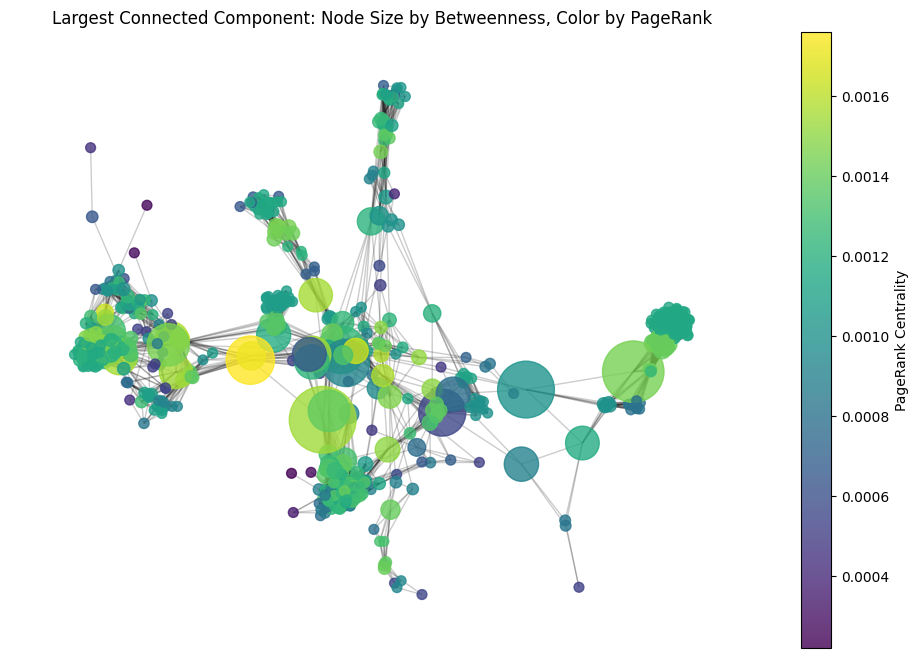

In [5]:
plt.figure(figsize=(12, 8))

# Visualize the LCC with node size reflecting Betweenness Centrality
pos = nx.spring_layout(LCC, k=0.15, iterations=20, seed=42)

node_sizes = [betweenness_centrality[node] * 10000 + 50 for node in LCC.nodes()]
node_colors = [pagerank_centrality[node] for node in LCC.nodes()]

nx.draw_networkx_edges(LCC, pos, alpha=0.2)
nodes = nx.draw_networkx_nodes(LCC, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.viridis, alpha=0.8)

plt.colorbar(nodes, label='PageRank Centrality')
plt.title("Largest Connected Component: Node Size by Betweenness, Color by PageRank")
plt.axis('off')
plt.savefig('centrality_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretation

In this network, we see that high-degree nodes (hubs) often correspond to high betweenness nodes, but not always. Nodes like **KhaledMashal** and **Abu Khaled** show significant centrality across multiple measures, indicating their role as both popular connectors and critical bridges in the terrorist relationship network. 

The diameter of 14 in the largest connected component suggests a relatively small-world structure given the number of nodes, although the low density indicates that connections are sparse and organized into specific operational cells. The clustering coefficient of 0.5748 is significantly higher than what would be expected in a random graph, pointing towards the existence of tight-knit groups or "trusted circles" within the network.